# Análisis de Emociones usando LSTM

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/rchicangana/icesi_nlp/blob/main/Session%202/Taller/Taller_NLP_Sesion_2_Emotion_Analysis.ipynb)

### *Entregado por:*


*   Laura Isabel Chaparro Navia
*   Ricardo Chicangana
*   Fabian Ortiz Collazos


---


Emotion es un conjunto de datos de mensajes de Twitter en inglés con seis emociones básicas: ira, miedo, alegría, amor, tristeza y sorpresa. El objetivo de este notebook es desarrollar un modelo LSTM capaz de clasificar correctamente la emoción expresada en un texto.

## Instalación de Dependencias
Instalamos las librerías necesarias para el preprocesamiento de los datos y la construcción del modelo.


In [2]:
import sys
!{sys.executable} -m pip install datasets pytorch-lightning torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 70.7 MB/s eta 0:00:00


## Importación de Librerías


In [3]:
import torch
from datasets import load_dataset, concatenate_datasets
import pandas as pd
import re
from collections import Counter
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from typing import Tuple, Dict
from torch.utils.data import Dataset
from pytorch_lightning import LightningModule, Trainer
from pytorch_lightning.loggers import TensorBoardLogger
from pytorch_lightning.callbacks.early_stopping import EarlyStopping
from torchmetrics import Accuracy
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedShuffleSplit
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Carga de Datos
Cargamos el dataset `dair-ai/emotion`, que contiene mensajes etiquetados con 6 posibles emociones (sadness, joy, love, anger, fear, surprise).

Cabe resaltar que el dataset cuenta con dos opciones de descarga:

1.   Dataset completo (417.000)
2.   Parte del dataset con splits para entrenamiento (16.000), validación (2.000) y test (2.000)

Decidimos utilizar el dataset con splits predefinidos, ya que entrenar el modelo con el conjunto completo tomaba más de 30 minutos por época. Esto limitaba el tiempo de uso de GPU disponible para realizar la actividad.




In [4]:
# Carga del dataset completo
#dataset = load_dataset('dair-ai/emotion', 'unsplit')

# Carga del dataset con splits
dataset = load_dataset('dair-ai/emotion')

print("Dataset cargado correctamente")
print(dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Dataset cargado correctamente
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})


## Exploración de Datos
Concatenamos todos los splits (entrenamiento, validación y prueba) para realizar un análisis inicial general de todos los datos.


In [5]:
full_dataset = concatenate_datasets([
    dataset["train"],
    dataset["validation"],
    dataset["test"]
])

df = full_dataset.to_pandas()

print("Dataframe de pandas:")
df.head(10)

Dataframe de pandas:


,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3
5,ive been feeling a little burdened lately wasn...,0
6,ive been taking or milligrams or times recomme...,5
7,i feel as confused about life as a teenager or...,4
8,i have been with petronas for years i feel tha...,1
9,i feel romantic too,2


Mapeamos los identificadores numéricos a sus respectivas etiquetas textuales, para facilitar su lectura y análisis.


In [6]:
label_mapping = {
    0: 'sadness',
    1: 'joy',
    2: 'love',
    3: 'anger',
    4: 'fear',
    5: 'surprise'
}

df['label'] = df['label'].replace(label_mapping)
df.head(10)

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger
5,ive been feeling a little burdened lately wasn...,sadness
6,ive been taking or milligrams or times recomme...,surprise
7,i feel as confused about life as a teenager or...,fear
8,i have been with petronas for years i feel tha...,joy
9,i feel romantic too,love


Número de registros por emoción:

In [7]:
Counter(df.label)

Counter({'sadness': 5797,
         'anger': 2709,
         'love': 1641,
         'surprise': 719,
         'fear': 2373,
         'joy': 6761})

## Análisis de Texto
Calculamos y visualizamos la distribución de la longitud de los textos en caracteres, para observar qué tan cortos o largos son.


In [8]:
df['text_length'] = df['text'].apply(len)
print("Estadísticas descriptivas de la longitud del texto (número de caracteres):")
df['text_length'].describe()

Estadísticas descriptivas de la longitud del texto (número de caracteres):


,text_length
count,20000.000000
mean,96.670050
std,55.777923
min,7.000000
25%,53.000000
50%,86.000000
75%,129.000000
max,300.000000


También calculamos la longitud basada en la cantidad de palabras, lo cual nos sirve posteriormente para decidir la longitud máxima de secuencias en nuestro modelo LSTM.


In [9]:
df['word_count'] = df['text'].apply(lambda x: len(x.split()))
print("Estadísticas descriptivas del número de palabras por texto:")
df['word_count'].describe()

Estadísticas descriptivas del número de palabras por texto:


,word_count
count,20000.000000
mean,19.135050
std,10.972016
min,2.000000
25%,11.000000
50%,17.000000
75%,25.000000
max,66.000000


In [10]:
df['avg_word_length'] = df['text_length'] / df['word_count']
print("Estadísticas descriptivas de la longitud promedio de las palabras por texto:")
df['avg_word_length'].describe()

Estadísticas descriptivas de la longitud promedio de las palabras por texto:


,avg_word_length
count,20000.000000
mean,5.074364
std,0.564732
min,3.200000
25%,4.700000
50%,5.000000
75%,5.400000
max,9.777778


De las estadísticas del texto podemos resaltar:

*   Texto más largo: 300 carácteres
*   Texto más corto: 7 carácteres
*   El 50% de los textos cuenta con 86 carácteres

De las estadísticas del número de palabras en la oración podemos resaltar:

*   Máximo: 66
*   Mínimo: 2
*   El 50% está en 17 palabras

Si el valor de la estadística de la longitud promedio de las palabras por texto es pequeña significa que hay más palabras cortas en cambio si la estadísticas es alta hay palabras más largas.

*   En promedio los textos tienen un mínimo de 3 palabras y hasta 9 palabras.
*   El 50% de los textos tiene 5 palabras.

A continuación eliminamos las columnas de *'text_length', 'word_count', 'avg_word_length'* debido a que solo se utilizan para realizar análisis.




In [11]:
columns_to_drop = ['text_length', 'word_count', 'avg_word_length']
df = df.drop(columns=columns_to_drop)
df.head()

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


## Tokenización y Vocabulario
Implementamos un tokenizador simple utilizando expresiones regulares. A continuación, construimos el vocabulario tomando en cuenta los tokens más frecuentes, limitando el tamaño del diccionario a 50,000 entradas (reservando espacio para `[PAD]` y `[UNK]`).


In [12]:
def simple_tokenizer(text):
    text = text.lower()
    text = re.sub(r"[^a-záéíóúüñ]+", " ", text)
    return text.strip().split()

# Construimos el vocabulario a partir de conjunto de datos.
token_counts = Counter()
for text in df["text"]:
    token_counts.update(simple_tokenizer(text))

# 50k-2 porque necesitamos reservar espacio para los dos tokens especiales
top_n_tokens = list(token_counts.keys())[:50000-2]
vocab = {"[PAD]": 0, "[UNK]": 1}
for token in top_n_tokens:
    vocab[token] = len(vocab)

def tokenize_text(text, max_length=50):
    tokens = simple_tokenizer(text)
    ids = [vocab.get(tok, vocab["[UNK]"]) for tok in tokens[:max_length]]
    ids += [vocab["[PAD]"]] * (max_length - len(ids))
    return ids

In [13]:
print(f"Vocabulario: {len(vocab)} tokens")
print("Primeros 15 tokens:")
top_n_tokens[:15]

Vocabulario: 17098 tokens
Primeros 15 tokens:


['i',
 'didnt',
 'feel',
 'humiliated',
 'can',
 'go',
 'from',
 'feeling',
 'so',
 'hopeless',
 'to',
 'damned',
 'hopeful',
 'just',
 'being']

In [14]:
print("Últimos 15 tokens:")
top_n_tokens[-15:]

Últimos 15 tokens:


['balmy',
 'judgmental',
 'scenarios',
 'trafficking',
 'slavery',
 'embittered',
 'blunder',
 'refine',
 'poses',
 'sadder',
 'advil',
 'inflammation',
 'infact',
 'delilahlwl',
 'raping']

Definición del dataset de pytorch

In [15]:
class commentsDataset(Dataset):

    def __init__(self, tokenizer, dataset, seq_length: int = 512):
        self.tokenizer = tokenizer
        self.dataset = dataset
        self.seq_length = seq_length
        # Definimos estos dos mapas para facilitarnos la tarea
        # de traducir de sentimientos a ids de sentimientos.
        self.id_2_class_map = dict(enumerate(np.unique(dataset[:]['label'])))
        self.class_2_id_map = {v: k for k, v in self.id_2_class_map.items()}
        self.num_classes = len(self.id_2_class_map)

    def __getitem__(self, index) -> Dict[str, torch.Tensor]:
        # Usar .iloc para acceder a la fila por posición entera de forma segura
        text, y = self.dataset.iloc[index]['text'], self.dataset.iloc[index]['label']
        y = self.class_2_id_map[y]
        data = {'input_ids': torch.tensor(self.tokenizer(text, max_length=self.seq_length))}
        data['y'] = torch.tensor(y)
        return data


    def __len__(self):
        return len(self.dataset)

Una forma de identificar la lógitud óptima es por medio de los percentiles. p90 o superior sería una buena aproximación para capturar la mayor cantidad de información, reduciendo la necesidad de truncar o rellenar (pad) tweets.

In [16]:
lengths = df["text"].apply(lambda x: len(tokenize_text(x)))
np.percentile(lengths, [90, 95, 99])

array([50., 50., 50.])

Teniendo en cuenta que el percentil 90 fue de 50 caracteres se selecciona cómo max_len=64.

In [17]:
max_len = 64
comments_dataset = commentsDataset(tokenize_text, df, seq_length=max_len)
print(f"Número de elementos en el dataset: {len(comments_dataset)}")
print(f"Número de clases: {comments_dataset.num_classes}")
print(f"Mapeo de ID a Clase: {comments_dataset.id_2_class_map}")
print(f"Mapeo de Clase a ID: {comments_dataset.class_2_id_map}")

Número de elementos en el dataset: 20000
Número de clases: 6
Mapeo de ID a Clase: {0: 'anger', 1: 'fear', 2: 'joy', 3: 'love', 4: 'sadness', 5: 'surprise'}
Mapeo de Clase a ID: {'anger': 0, 'fear': 1, 'joy': 2, 'love': 3, 'sadness': 4, 'surprise': 5}


Vamos a observar cómo quedo tokenizado el texto:

In [18]:
# Re-create id_2_token mapping for readability
id_2_token = {v: k for k, v in vocab.items()}

print("Primeros 4 ejemplos de comments_dataset:")
for i in range(4):
    sample = comments_dataset[i]
    input_ids = sample['input_ids'].tolist()
    label_id = sample['y'].item()

    # Convert input_ids back to text (ignoring special tokens like [PAD] and [UNK])
    special_tokens_to_ignore = {vocab['[PAD]'], vocab['[UNK]']}
    text_tokens = [id_2_token[idx] for idx in input_ids if idx not in special_tokens_to_ignore and idx < len(id_2_token)]
    original_text = ' '.join(text_tokens)

    label_name = comments_dataset.id_2_class_map[label_id]

    print(f"\n--- Ejemplo {i+1} ---")
    print(f"Texto original (reconstruido): {original_text}")
    print(f"Longitud de IDs de entrada: {len(input_ids)}")
    print(f"IDs de entrada: {input_ids[:35]}...")
    print(f"Etiqueta (ID): {label_id}")
    print(f"Etiqueta (Nombre): {label_name}")

Primeros 4 ejemplos de comments_dataset:

--- Ejemplo 1 ---
Texto original (reconstruido): i didnt feel humiliated
Longitud de IDs de entrada: 64
IDs de entrada: [2, 3, 4, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]...
Etiqueta (ID): 4
Etiqueta (Nombre): sadness

--- Ejemplo 2 ---
Texto original (reconstruido): i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
Longitud de IDs de entrada: 64
IDs de entrada: [2, 6, 7, 8, 9, 10, 11, 12, 10, 13, 14, 15, 8, 16, 17, 18, 19, 20, 21, 22, 23, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]...
Etiqueta (ID): 4
Etiqueta (Nombre): sadness

--- Ejemplo 3 ---
Texto original (reconstruido): im grabbing a minute to post i feel greedy wrong
Longitud de IDs de entrada: 64
IDs de entrada: [24, 25, 26, 27, 12, 28, 2, 4, 29, 30, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]...
Etiqueta (ID): 0
Etiqueta (Nombre): anger

--- E

Dividir el dataset manteniendo la proporción inicial de todos los sentimientos del dataset original. Para ello se utiliza la función StratifiedShuffleSplit.

In [19]:
all_labels = []
for i in range(len(comments_dataset)):
    sample = comments_dataset[i]
    all_labels.append(sample['y'].item())

# Proportions for train, validation, test
train_size = 0.7
val_size = 0.15
test_size = 0.15

# Get the indices of the full dataset
all_indices = list(range(len(comments_dataset)))

# First split: train vs (validation + test)
sss1 = StratifiedShuffleSplit(n_splits=1, test_size=(val_size + test_size), random_state=42)
for train_idx, temp_idx in sss1.split(all_indices, all_labels):
    train_indices = train_idx
    temp_indices = temp_idx

# Get labels for the temporary set to stratify the next split
temp_labels = [all_labels[i] for i in temp_indices]

# Second split: validation vs test from the temporary set
# Calculate the proportion of test_size relative to the temporary set size
relative_test_size = test_size / (val_size + test_size)
sss2 = StratifiedShuffleSplit(n_splits=1, test_size=relative_test_size, random_state=42)
for val_idx, test_idx in sss2.split(temp_indices, temp_labels):
    val_indices = [temp_indices[i] for i in val_idx]
    test_indices = [temp_indices[i] for i in test_idx]

# Create subsets for each split using the indices
train_subset = torch.utils.data.Subset(comments_dataset, train_indices)
val_subset = torch.utils.data.Subset(comments_dataset, val_indices)
test_subset = torch.utils.data.Subset(comments_dataset, test_indices)


## DataLoaders
Una vez dividido el dataset usando una separación estratificada (para balanceo), construimos nuestros objetos DataLoader para manejar los baches durante el entrenamiento, validación y prueba.


In [20]:
batch_size = 12
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"Tamaño del conjunto de entrenamiento: {len(train_subset)}")
print(f"Tamaño del conjunto de validación: {len(val_subset)}")
print(f"Tamaño del conjunto de prueba: {len(test_subset)}")

Tamaño del conjunto de entrenamiento: 14000
Tamaño del conjunto de validación: 3000
Tamaño del conjunto de prueba: 3000


Calculamos los pesos por cada clase para usarlos posteriormente en el clasificador como mecanismo de balanceo de clases.

In [21]:
# Pesos para clases minoritarias (inverso a la frecuencia en train)
train_labels = [train_subset[i]['y'].item() for i in range(len(train_subset))]
class_counts = Counter(train_labels)
n_total = len(train_labels)
n_classes = comments_dataset.num_classes
class_weights = torch.tensor(
    [n_total / (n_classes * class_counts.get(c, 1)) for c in range(n_classes)],
    dtype=torch.float32
)
print("Pesos por clase (mayor = mas peso a minoritarias):", {comments_dataset.id_2_class_map[i]: round(class_weights[i].item(), 3) for i in range(n_classes)})

Pesos por clase (mayor = mas peso a minoritarias): {'anger': 1.231, 'fear': 1.405, 'joy': 0.493, 'love': 2.031, 'sadness': 0.575, 'surprise': 4.639}


## Arquitectura del Modelo: Bloque LSTM
Definimos nuestro módulo extractor de características (LSTMBlock). Es de resaltar que creamos una **máscara de padding** para sumar los vectores de salida únicamente para las palabras reales, calculando así el promedio exacto de los tokens relevantes de cada oración.


In [22]:
class LSTMBlock(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, num_layers=2, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout)

    def forward(self, x):
      # Crear una máscara: 1 donde hay palabras, 0 donde hay PAD
      mask = (x != 0).unsqueeze(-1).float()

      embedded = self.embedding(x)
      output, _ = self.lstm(embedded)

      # Sumar solo los vectores de palabras reales
      summed = torch.sum(output * mask, dim=1)
      # Contar solo las palabras reales para dividir
      counts = torch.clamp(mask.sum(dim=1), min=1e-9)

      return summed / counts

## Modelo Clasificador con PyTorch Lightning
Para el pipeline del clasificador realizamos una arquitecturea con linealización, normalización de lotes, ReLU y validación mediante Dropout para evitar sobreajuste.

Adicionalemente agregamos los siguientes metodos:

`on_train_epoch_end` y `on_validation_epoch_end` se utilizan para guardar el accuracy en cada época con el fin de graficar posteriormente su comportamiento y poder observar si hay overfitting.

Se modificó `configure_optimizers` agregando ReduceLROnPlateau con el fin de colocar un optimizador parametrizado que cambie el learning rate de forma dinámica en función de la mejoría del modelo.  

In [23]:
class commentsClassifierWithLSTM(LightningModule):

    def __init__(self, vocab_size: int, num_classes: int, emb_dim: int, hidden_dim: int = 128, class_weights=None):
        super(commentsClassifierWithLSTM, self).__init__()
        self.num_classes = num_classes

        if class_weights is not None:
            self.register_buffer('class_weights', class_weights.float())
        else:
            self.class_weights = None

        self.lstm = LSTMBlock(vocab_size, emb_dim, hidden_dim, num_classes)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(hidden_dim, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, num_classes),
        )

        self.train_acc = Accuracy(task='multiclass', num_classes=num_classes)
        self.val_acc = Accuracy(task='multiclass', num_classes=num_classes)
        self.test_acc = Accuracy(task='multiclass', num_classes=num_classes)

        # Agregado para guardar las accuracies de cada época
        self.train_epoch_accuracies = []
        self.val_epoch_accuracies = []

    def forward(self, x):
        embeddings = self.lstm(x)
        return self.classifier(embeddings)


    def training_step(self, batch, batch_idx):
        x, y = batch['input_ids'], batch['y']
        y_hat = self(x)
        loss = F.cross_entropy(y_hat, y, weight=self.class_weights)
        self.train_acc(y_hat, y)
        self.log('train-loss', loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log('train-acc', self.train_acc, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def on_train_epoch_end(self):
        # Obtener la accuracy de entrenamiento de la época y guardarla
        epoch_train_acc = self.trainer.callback_metrics['train-acc'].item()
        self.train_epoch_accuracies.append(epoch_train_acc)

    def validation_step(self, batch):
        x, y = batch['input_ids'], batch['y']
        y_hat = self(x)
        loss = F.cross_entropy(y_hat, y)
        self.val_acc(y_hat, y)
        self.log('val-loss', loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log('val-acc', self.val_acc, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def on_validation_epoch_end(self):
        # Obtener la accuracy de validación de la época y guardarla
        epoch_val_acc = self.trainer.callback_metrics['val-acc'].item()
        self.val_epoch_accuracies.append(epoch_val_acc)

    def test_step(self, batch):
        x, y = batch['input_ids'], batch['y']
        y_hat = self(x)
        self.test_acc(y_hat, y)
        self.log('test-acc', self.test_acc, prog_bar=True, on_step=False, on_epoch=True)


    def predict_step(self, batch):
        x = batch['input_ids']
        return self(x)


    def configure_optimizers(self):
            optimizer = torch.optim.AdamW(self.parameters(), lr=1e-2, weight_decay=1e-5)
            scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                optimizer, mode='min', factor=0.5, patience=2, min_lr=1e-6
            )
            return {
                'optimizer': optimizer,
                'lr_scheduler': {
                    'scheduler': scheduler,
                    'monitor': 'val-loss',
                    'interval': 'epoch',
                    'frequency': 1,
                },
            }

Para la configuración del modelo utilizamos un tamaño de embedding de 24 junto con un número de capas escondidas de 64.

In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Re-instantiate the model so the changes to the class take effect
model = commentsClassifierWithLSTM(vocab_size=len(vocab) + 1, emb_dim=24,num_classes=comments_dataset.num_classes, hidden_dim=64)
model = model.to(device)
model

commentsClassifierWithLSTM(
  (lstm): LSTMBlock(
    (embedding): Embedding(17099, 24, padding_idx=0)
    (lstm): LSTM(24, 64, num_layers=2, batch_first=True, dropout=0.2)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=64, out_features=32, bias=True)
    (2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU()
    (4): Dropout(p=0.3, inplace=False)
    (5): Linear(in_features=32, out_features=6, bias=True)
  )
  (train_acc): MulticlassAccuracy()
  (val_acc): MulticlassAccuracy()
  (test_acc): MulticlassAccuracy()
)

## Entrenamiento del Modelo

In [25]:
tb_logger = TensorBoardLogger('tb_logs', name='LSTMClassifier')
callbacks=[EarlyStopping(monitor='val-loss', patience=3, mode='min')]
trainer = Trainer(max_epochs=10, devices=1, logger=tb_logger, callbacks=callbacks, precision="16-mixed")

# Re-run training to collect accuracies
trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)

INFO:pytorch_lightning.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not supported by 

┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ lstm       │ LSTMBlock          │  466 K │ train │     0 │
│ 1 │ classifier │ Sequential         │  2.3 K │ train │     0 │
│ 2 │ train_acc  │ MulticlassAccuracy │      0 │ train │     0 │
│ 3 │ val_acc    │ MulticlassAccuracy │      0 │ train │     0 │
│ 4 │ test_acc   │ MulticlassAccuracy │      0 │ train │     0 │
└───┴────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 469 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 469 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.


In [26]:
model.eval()
trainer.test(model, dataloaders=test_loader)

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test-acc          │    0.9380000233650208     │
└───────────────────────────┴───────────────────────────┘

[{'test-acc': 0.9380000233650208}]

## Análisis de Rendimiento
Comparamos visualmente el comportamiento del 'Accuracy' durante el entrenamiento y la validación en el transcurso de las épocas.


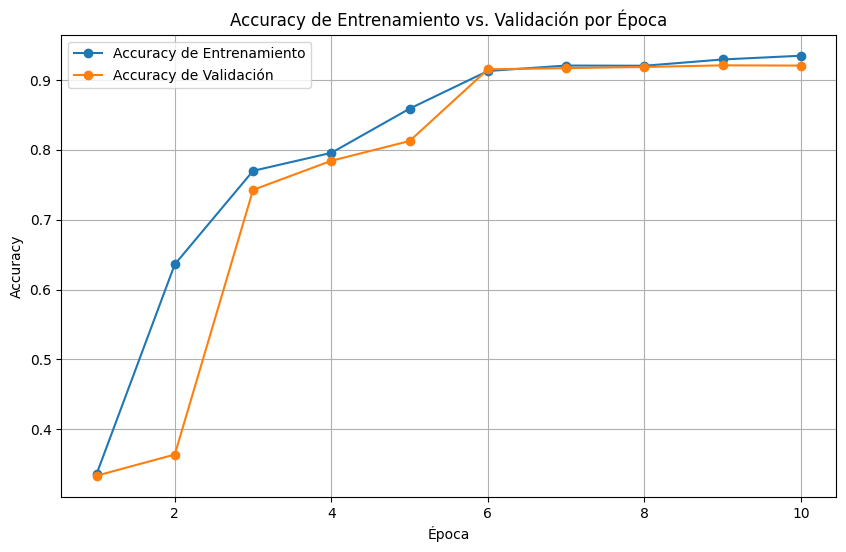

In [27]:
train_accuracies = model.train_epoch_accuracies
val_accuracies = model.val_epoch_accuracies

# Ajustar la longitud de las listas para que coincidan con la longitud mínima
min_epochs = min(len(train_accuracies), len(val_accuracies))
train_accuracies = train_accuracies[:min_epochs]
val_accuracies = val_accuracies[:min_epochs]

epochs = range(1, min_epochs + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, train_accuracies, 'o-', label='Accuracy de Entrenamiento')
plt.plot(epochs, val_accuracies, 'o-', label='Accuracy de Validación')
plt.title('Accuracy de Entrenamiento vs. Validación por Época')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

Se puede observar que la precisión del modelo en la clasificación de emociones mejora con cada época de entrenamiento. Tanto la curva de entrenamiento como la de validación crecen de forma conjunta y se estabilizan hacia el final, alcanzando niveles altos de precisión.

La curva de validación se mantiene cercana a la de entrenamiento, por lo que no se puede afirmar que exista overfitting. Sin embargo, a partir de la época 8 ambas curvas comienzan a separarse: mientras la precisión de validación se mantiene relativamente estable, la de entrenamiento continúa mejorando. Esto sugiere que, si se incrementa el número de épocas, podría comenzar a aparecer overfitting.

## Predicción y Evaluación
Realizamos la predicción de cada muestra en el conjunto de pruebas usando el modelo entrenado y obtenemos las etiquetas de texto correspondientes.


In [28]:
predictions = trainer.predict(model, dataloaders=test_loader)
predictions = torch.cat(predictions, dim=0)
predictions = torch.argmax(predictions, dim=1)
predictions = [comments_dataset.id_2_class_map[pred.item()] for pred in predictions]
predictions[:10]

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

['love',
 'sadness',
 'fear',
 'sadness',
 'joy',
 'joy',
 'joy',
 'sadness',
 'joy',
 'joy']

## Análisis de Errores Críticos
Para entender las errores del modelo, aislamos las predicciones erróneas, donde difiere la etiqueta predicha y la etiqueta real.


In [29]:
true_labels_test_set_numerical = [comments_dataset.class_2_id_map[comments_dataset.dataset.iloc[i]['label']] for i in test_subset.indices]

# Convert these numerical true labels to their string names for comparison
true_labels_test_set_names = [comments_dataset.id_2_class_map[label_id] for label_id in true_labels_test_set_numerical]

# Create a temporary DataFrame for the test set to facilitate comparison
test_results_df = df.iloc[test_subset.indices].copy()
test_results_df['true_label'] = true_labels_test_set_names
test_results_df['predicted_label'] = predictions

# Filter for rows where the true label does not match the predicted label
erroneous_predictions_df = test_results_df[test_results_df['true_label'] != test_results_df['predicted_label']]

print(f"Número total de muestras en el conjunto de prueba: {len(test_results_df)}")
print(f"Número de predicciones erróneas encontradas: {len(erroneous_predictions_df)}")
print("\nPrimeras 10 predicciones erróneas (Texto, Etiqueta Real, Etiqueta Predicha):")
erroneous_predictions_df[['text', 'true_label', 'predicted_label']].head(10)

Número total de muestras en el conjunto de prueba: 3000
Número de predicciones erróneas encontradas: 186

Primeras 10 predicciones erróneas (Texto, Etiqueta Real, Etiqueta Predicha):


,text,true_label,predicted_label
8960,i feel the responsibility of loving them even ...,love,joy
422,i feel blessed amazed and yes very excited,love,surprise
17128,i am feeling a little stressed to think that t...,anger,sadness
9769,i often find myself feeling assaulted by a mul...,sadness,fear
7895,first anatomy lesson,anger,fear
15215,i still feel slightly strange with sorrow but ...,surprise,fear
18560,i do know that i tell some people if i feel th...,joy,anger
3254,i do feel my beloved husbands spirit more and ...,love,joy
18833,i feel my truth is accepted and not judged bec...,love,joy
13704,is eyes its questionable whether shes feeling ...,love,joy


Detección de falencias con  **negaciones**. Usualmente el modelo tiene complicaciones al identificar inversiones de sentimiento, por ejemplo al procesar 'I'm not happy'. Obtenemos estos casos.


In [30]:
# Lista de palabras de negación y contracciones comunes en inglés
negation_words = [
    'no', 'not', 'never', 'none', 'neither', 'nor', 'nothing', 'nowhere',
    'hardly', 'scarcely', 'barely', 'without', 'cannot',
    'can\'t', 'don\'t', 'doesn\'t', 'isn\'t', 'aren\'t', 'wasn\'t', 'weren\'t',
    'won\'t', 'wouldn\'t', 'shouldn\'t', 'couldn\'t', 'haven\'t', 'hasn\'t', 'hadn\'t'
]

# Crear el patrón de regex
# El uso de \b asegura que busque palabras completas, detectando 'no' pero ignorando 'now'
negation_pattern = re.compile(r'\b(' + '|'.join(negation_words) + r')\b', re.IGNORECASE)

# Función para detectar negaciones
def contains_negation(text):
    return bool(negation_pattern.search(text))

# Aplicar al DataFrame
erroneous_predictions_df['contains_negation'] = erroneous_predictions_df['text'].apply(contains_negation)

# Filtrar las predicciones erróneas
negation_errors = erroneous_predictions_df[erroneous_predictions_df['contains_negation']]

print(f"Número total de predicciones erróneas: {len(erroneous_predictions_df)}")
print(f"Número de predicciones erróneas con negaciones: {len(negation_errors)}")

print("\nPrimeras 10 predicciones erróneas que contienen negaciones:")
negation_errors[['text', 'true_label', 'predicted_label']].head(10)

Número total de predicciones erróneas: 186
Número de predicciones erróneas con negaciones: 38

Primeras 10 predicciones erróneas que contienen negaciones:


/tmp/ipykernel_703/4216370859.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  erroneous_predictions_df['contains_negation'] = erroneous_predictions_df['text'].apply(contains_negation)


,text,true_label,predicted_label
15215,i still feel slightly strange with sorrow but ...,surprise,fear
18833,i feel my truth is accepted and not judged bec...,love,joy
473,im not one of those people who can bury all th...,love,joy
17488,i cannot imagine what african americans feel i...,anger,love
6907,im very much the opposite of it my cool is bas...,love,joy
16907,i like the three finger hands those simple det...,sadness,love
18994,i should stop reading sids blogs but it is par...,love,joy
4561,i vow to be gasp nicer to everyone not just a ...,love,joy
2487,i still did not really feel like myself and i ...,anger,joy
16165,i am just feeling overwhelmed and there is not...,surprise,fear


Detección de falencias con **modificadores de grado** o intensificadores (ej: 'very', 'quite'), en donde el contexto puede llegar a confundir los vectores.


Estadísticamente podemos afirmar que las negaciones no influyen en gran medida los resultados erroneos del modelo, debido a que de los 186 errores 38 tenían negaciones.

Es de resaltar que esta conclusión se basa en un grupo de palabras comunes predefinidas más no necesariamente negaciones existentes dentro del dataset.

In [31]:
# Lista de modificadores de grado (intensificadores) en inglés
modifier_words = [
    'quite', 'very', 'little', 'too', 'really', 'extremely',
    'almost', 'barely', 'somewhat', 'so', 'less', 'more',
    'most', 'highly', 'rather', 'just', 'fairly', 'totally'
]

# Crear el patrón de regex
modifier_pattern = re.compile(r'\b(' + '|'.join(modifier_words) + r')\b', re.IGNORECASE)

# Función para detectar modificadores en un texto
def contains_modifier(text):
    return bool(modifier_pattern.search(text))

# Aplicar al DataFrame
erroneous_predictions_df['contains_modifier'] = erroneous_predictions_df['text'].apply(contains_modifier)

# Filtrar las predicciones erróneas que contienen modificadores
modifier_errors = erroneous_predictions_df[erroneous_predictions_df['contains_modifier']]

print(f"Número total de predicciones erróneas: {len(erroneous_predictions_df)}")
print(f"Número de predicciones erróneas con modificadores: {len(modifier_errors)}")

print("\nPrimeras 10 predicciones erróneas con modificadores (Texto, Etiqueta Real, Etiqueta Predicha):")

modifier_errors[['text', 'true_label', 'predicted_label']].head(10)

Número total de predicciones erróneas: 186
Número de predicciones erróneas con modificadores: 77

Primeras 10 predicciones erróneas con modificadores (Texto, Etiqueta Real, Etiqueta Predicha):


/tmp/ipykernel_703/1231465971.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  erroneous_predictions_df['contains_modifier'] = erroneous_predictions_df['text'].apply(contains_modifier)


,text,true_label,predicted_label
8960,i feel the responsibility of loving them even ...,love,joy
422,i feel blessed amazed and yes very excited,love,surprise
17128,i am feeling a little stressed to think that t...,anger,sadness
3254,i do feel my beloved husbands spirit more and ...,love,joy
473,im not one of those people who can bury all th...,love,joy
14636,i feel very blessed to call them mom and dad,joy,love
17230,i don t always feel like i have amazing style ...,surprise,joy
19185,i start to feel a little overwhelmed knowing i...,surprise,fear
7434,i am feeling a little overwhelmed like i do ev...,surprise,fear
6907,im very much the opposite of it my cool is bas...,love,joy


Podemos observar que las palabras amplificadoras influyen en que el modelo cometa errores, ya que aparecen con frecuencia en muchos de los casos mal clasificados.

Esto puede deberse a que este tipo de palabras suelen utilizarse en contextos de ironía o sarcasmo, lo que dificulta que el modelo interprete correctamente la emoción del texto.

## Métricas Finales

In [32]:
accuracy = accuracy_score(true_labels_test_set_names, predictions)
print(f"Accuracy del modelo: {accuracy:.4f}")

f1 = f1_score(true_labels_test_set_names, predictions, average='weighted')
print(f"F1 Score (weighted) del modelo: {f1:.4f}")

class_names = [comments_dataset.id_2_class_map[i] for i in sorted(comments_dataset.id_2_class_map.keys())]
print("\nReporte de Clasificación:")
print(classification_report(true_labels_test_set_names, predictions, target_names=class_names))

Accuracy del modelo: 0.9380
F1 Score (weighted) del modelo: 0.9373

Reporte de Clasificación:
              precision    recall  f1-score   support

       anger       0.95      0.93      0.94       407
        fear       0.90      0.90      0.90       356
         joy       0.95      0.96      0.96      1014
        love       0.87      0.83      0.85       246
     sadness       0.95      0.99      0.97       869
    surprise       0.88      0.75      0.81       108

    accuracy                           0.94      3000
   macro avg       0.92      0.89      0.90      3000
weighted avg       0.94      0.94      0.94      3000



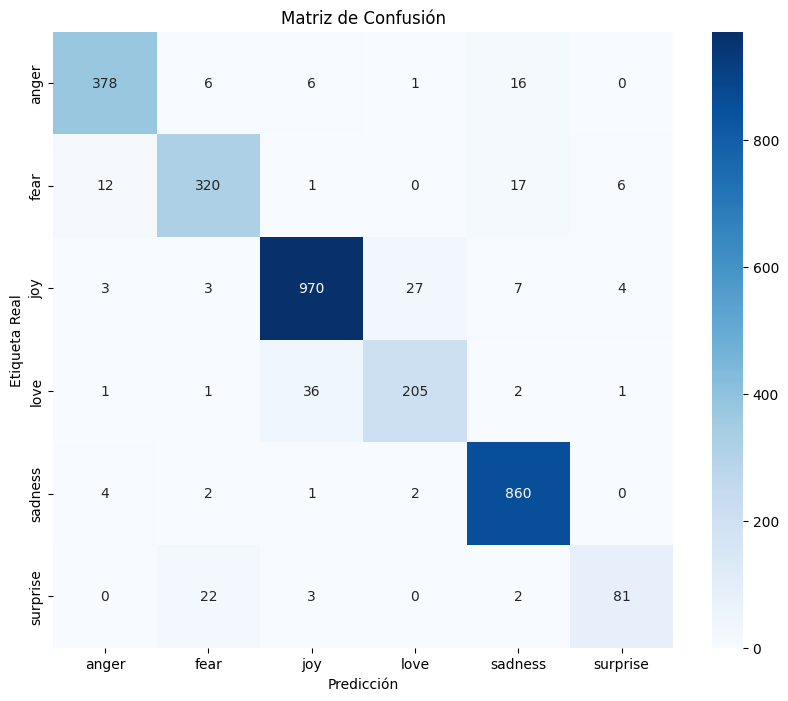

In [33]:
cm = confusion_matrix(true_labels_test_set_names, predictions)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicción')
plt.ylabel('Etiqueta Real')
plt.title('Matriz de Confusión')
plt.show()

Podemos observar que la emoción que más le cuesta clasificar al modelo es `surprise`, lo cual probablemente se debe a que es la que cuenta con menor cantidad de registros dentro del dataset.

Por otro lado, las emociones que el modelo clasifica con mayor precisión son `joy` y `sadness`, lo cual puede explicarse porque estas categorías tienen una mayor cantidad de ejemplos en el dataset.

La emoción `anger` también presenta buenas métricas, a pesar de no contar con tantos registros como otras emociones dentro del dataset.

Adicionalmente, en la matriz de confusión se observa que el modelo tiende a confundir `joy` con `love`. Esto puede deberse a la similitud semántica entre ambas emociones en ciertos contextos.

## Conclusiones

*   El modelo demostró un rendimiento sobresaliente, logrando un Accuracy del 93.80% y un F1-Score ponderado del 93.73% sobre el conjunto de prueba de 3,000 registros. En las pruebas realizadas se observó que incrementar el tamaño del embedding y el número de capas ocultas no traducía en mejoras significativas. Por lo tanto, se comprobó que una arquitectura más ligera (dimensión de embedding de 24 y 64 unidades ocultas en la LSTM) era suficiente y eficiente, no justificando el costo computacional de añadir más parámetros. Adicionalmente, la implementación de una máscara de padding para promediar únicamente los tokens reales (ignorando los ceros de relleno) fue un acierto fundamental para extraer características limpias del texto.

*   El cálculo y aplicación de pesos por categoría en la función de pérdida (otorgando mayor peso a clases minoritarias, como el peso de ~4.6 a `surprise` y ~2.0 a `love`) fue determinante. Esta estrategia obligó al modelo a prestar atención a todas las clases y no sesgarse hacia las categorías mayoritarias (`joy` y `sadness`). Como resultado, se obtuvieron métricas muy competitivas y equilibradas incluso en las clases con menos soporte.

*   Al evaluar las 186 predicciones erróneas, se evidenció que aunque el modelo tiene gran capacidad de generalización, presenta vulnerabilidades ante la complejidad semántica. Específicamente, al procesar modificadores de grado (amplificadores), presentes en 64 de los errores y en menor medida en inversiones de sentimiento (negaciones), estando presentes en 38 de los errores.

*   Durante la revisión manual de los errores, se encontró que hay registros en el dataset donde la predicción del modelo tiene más sentido semántico que la etiqueta real original. Esto pone en evidencia cierto grado de subjetividad o ruido en la recolección de los datos de Twitter. Asimismo, la matriz de confusión revela que existe una delgada línea entre emociones afines: es común la superposición entre sentimientos como 'love' y 'joy', o entre 'surprise' y 'fear', lo que justifica que la clase 'surprise' haya obtenido el recall más bajo (0.75).

## Trabajo futuro
*   Integrar un módulo de atención (Attention Mechanism) a la arquitectura LSTM o realizar pruebas de clasificación utilizando modelos basados en Transformers (como BERT o RoBERTa).

*   Experimentar con técnicas de Data Augmentation para NLP para incrementar artificialmente el número de ejemplos de las clases minoritarias.

